<a href="https://www.kaggle.com/code/abdullahaltepe/adult-income-fair-explainable-ml?scriptVersionId=332914008" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background:linear-gradient(135deg,#311B45 0%,#4A148C 45%,#7B1FA2 100%);padding:38px 30px;border-radius:16px;text-align:center;box-shadow:0 4px 14px rgba(49,27,69,.35);">
  <div style="color:#CE93D8;font-size:14px;letter-spacing:4px;text-transform:uppercase;">UCI Adult Census Income</div>
  <h1 style="color:#ffffff;margin:10px 0 6px;font-size:34px;font-weight:900;">Explainable &amp; Fair Machine Learning</h1>
  <p style="color:#E1BEE7;margin:0;font-size:16px;">Predicting whether a person earns &gt;&nbsp;$50K/year — end&#8209;to&#8209;end, with every decision explained.</p>
</div>

### How to read this notebook

This notebook is written so that **someone with zero machine-learning background can follow it**. It is not a code dump — every step answers three questions:

> **What** did we do? &nbsp;·&nbsp; **Why** did we do it? &nbsp;·&nbsp; **What did we learn** from it?

The work is split into four parts. Each builds on the one before it:

| Part | Name | The question it answers |
|------|------|-------------------------|
| **1** | Data Understanding & Cleaning | *Can I trust this data?* |
| **2** | Exploratory Data Analysis (EDA) | *What should I know before modeling?* |
| **3** | Feature Engineering | *How do I reshape the data so a model can learn from it?* |
| **4** | Modeling & Fairness | *Which model works — and is it fair?* |

<div style="background:#F3E5F5;border-left:5px solid #7B1FA2;padding:10px 16px;border-radius:6px;margin:12px 0;">
<b>The golden thread.</b> EDA is the <i>diagnosis</i>; feature engineering is the <i>treatment</i>. Nothing in Part 3 is invented — every transformation traces back to a specific finding in Part 2.
</div>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/uciml/adult-census-income/adult.csv


<div style="background:linear-gradient(90deg,#4A148C 0%,#7B1FA2 60%,#9C4DCC 100%);padding:20px 26px;border-radius:12px;margin:14px 0;box-shadow:0 2px 6px rgba(74,20,140,.25);">
  <div style="color:#E1BEE7;font-size:13px;letter-spacing:2px;text-transform:uppercase;margin-bottom:2px;">Part 1</div>
  <h1 style="color:#ffffff;margin:0;font-size:28px;font-weight:800;">Data Understanding &amp; Cleaning</h1>
  <p style="color:#F3E5F5;margin:8px 0 0;font-size:15px;">Before any analysis, make the data trustworthy: understand every column, find hidden gaps, and fix them without introducing bias.</p>
</div>

In [2]:
df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/adult-census-income/adult.csv")
df.head()



,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">1.1</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">Column Dictionary</span>
</div>

Before touching the data, we write down what each column *means* and whether it is **numerical** (a quantity, like age) or **categorical** (a label, like job type). This single habit prevents most beginner mistakes later — for example, accidentally treating a category as if it were a number.

| Column | Description | Type |
|--------|-------------|------|
| age | Age of the person | Numerical |
| workclass | Type of employment (private, gov, self-employed) | Categorical |
| fnlwgt | Census population weight (technical — will drop) | Numerical |
| education | Education level (HS, Bachelors, Masters) | Categorical |
| education.num | Numeric version of education (HS=9, Bachelors=13) | Numerical |
| marital.status | Marital status | Categorical |
| occupation | Job type | Categorical |
| relationship | Family relationship (husband, wife, child) | Categorical |
| race | Race | Categorical |
| sex | Gender | Categorical |
| capital.gain | Investment profit ($) | Numerical |
| capital.loss | Investment loss ($) | Numerical |
| hours.per.week | Weekly working hours | Numerical |
| native.country | Country of origin | Categorical |
| **income** | **Target variable (&gt;50K or &lt;=50K)** | Categorical |

<div style="background:#FFF8E1;border-left:5px solid #F9A825;padding:10px 16px;border-radius:6px;margin:12px 0;">
<b>💡 Takeaway.</b> <code>income</code> is the <b>target</b> — the thing we want to predict. Everything else is a potential <b>feature</b> (an input clue).
</div>

In [3]:
print(f"Number of columns: {len(df.columns)}")
print(df.columns.tolist())

Number of columns: 15
['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


The next cell is a quick "first look" — shape, data types, summary statistics, and a peek at the rows. You run these every time you meet a new dataset, the way a doctor takes vitals before anything else.

In [4]:
df.shape
df.info()
df.describe()
df.head(10)
df.isnull().sum()
df.nunique()
df.select_dtypes(include='object').head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
0,?,HS-grad,Widowed,?,Not-in-family,White,Female,United-States,<=50K
1,Private,HS-grad,Widowed,Exec-managerial,Not-in-family,White,Female,United-States,<=50K
2,?,Some-college,Widowed,?,Unmarried,Black,Female,United-States,<=50K
3,Private,7th-8th,Divorced,Machine-op-inspct,Unmarried,White,Female,United-States,<=50K
4,Private,Some-college,Separated,Prof-specialty,Own-child,White,Female,United-States,<=50K


<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">1.2</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">Finding the Missing Data (the hidden &quot;?&quot; trap)</span>
</div>

**What we did.** Checked for missing values.

**Why it's tricky here.** `df.isnull()` reports **zero** nulls — but that's a trap. In this dataset, missing values were recorded as the text `"?"` (sometimes with a leading space, `" ?"`). To pandas, `"?"` is a perfectly valid string, not a gap. So we must first **convert `"?"` into a real NaN**, and only *then* count how much is missing.

<div style="background:#FDECEA;border-left:5px solid #E53935;padding:10px 16px;border-radius:6px;margin:12px 0;">
<b>⚠️ Watch out.</b> Always sanity-check for placeholder missing values like <code>&quot;?&quot;</code>, <code>&quot;N/A&quot;</code>, <code>-1</code>, or <code>0</code>. A dataset that looks complete often isn&#39;t.
</div>

In [5]:
# Check if nulls are actually "?" marks
df.replace(" ?", pd.NA, inplace=True)
df.isnull().sum()



age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [6]:
null_counts = df.isnull().sum()
null_percentage = (df.isnull().sum() / len(df)) * 100
null_summary = pd.DataFrame({'null_count': null_counts, 'null_percentage': null_percentage})
null_summary[null_summary['null_count'] > 0]


,null_count,null_percentage


In [7]:
# Check if " ?" exists with space
df.isin([" ?"]).sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [8]:
df.replace("?", pd.NA, inplace=True)
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">1.3</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">Handling the Missing Values</span>
</div>

**What we found.** After converting `"?"` → NaN, exactly three columns have gaps:

| Column | Null count | Percentage | Type |
|--------|-----------|------------|------|
| workclass | 1,836 | ~5.6% | Categorical |
| occupation | 1,843 | ~5.7% | Categorical |
| native.country | 583 | ~1.8% | Categorical |

**The three options we weighed.**

1. **Fill with "Unknown"** — keeps every row, but invents a fake category the model may treat as a real job/country.
2. **Fill with the mode (most common value)** — keeps every row, but *guesses*. Labelling an unknown worker "Private" just because it's common inserts false information.
3. **Drop the rows** — costs ~5% of the data, but every surviving row is fully trustworthy.

Before choosing, we do something most beginners skip: **check who we'd be deleting.**

In [9]:
# Who are the null rows?
null_rows = df[df.isnull().any(axis=1)]
print(f"Rows with nulls: {len(null_rows)}")

# Gender distribution in null rows vs full data
print("== Null rows - sex ==")
print(null_rows.sex.value_counts(normalize=True))
print("\n== Full data - sex ==")
print(df.sex.value_counts(normalize=True))

# Age distribution in null rows vs full data
print("== Null rows - age ==")
print(null_rows.age.describe())
print("\n== Full data - age ==")
print(df.age.describe())

# Income distribution in null rows vs full data
print("== Null rows - income ==")
print(null_rows.income.value_counts(normalize=True))
print("\n== Full data - income ==")
print(df.income.value_counts(normalize=True))

# Are workclass and occupation both null together?
both_null = df[df.workclass.isnull() & df.occupation.isnull()]
print(f"Both workclass AND occupation null: {len(both_null)}")
print(f"Total null rows: {len(null_rows)}")

# Income distribution of null rows
print(null_rows.income.value_counts())


Rows with nulls: 2399
== Null rows - sex ==
sex
Male      0.587745
Female    0.412255
Name: proportion, dtype: float64

== Full data - sex ==
sex
Male      0.669205
Female    0.330795
Name: proportion, dtype: float64
== Null rows - age ==
count    2399.000000
mean       40.388912
std        18.786609
min        17.000000
25%        22.000000
50%        36.000000
75%        58.000000
max        90.000000
Name: age, dtype: float64

== Full data - age ==
count    32561.000000
mean        38.581647
std         13.640433
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64
== Null rows - income ==
income
<=50K    0.861192
>50K     0.138808
Name: proportion, dtype: float64

== Full data - income ==
income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64
Both workclass AND occupation null: 1836
Total null rows: 2399
income
<=50K    2066
>50K      333
Name: count, dtype: int64


<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">1.4</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">Bias Check — who are we about to remove?</span>
</div>

The missing rows are **not random**. Compared to the full dataset:

| Metric | Null rows | Full data | Concern |
|--------|-----------|-----------|---------|
| Female ratio | 41% | 33% | Women over-represented among the gaps |
| Age spread (std) | 18.7 | 13.6 | More very young / very old people |
| &lt;=50K ratio | 86% | 76% | Low-income over-represented |

On top of that, **1,836 of the null rows have *both* `workclass` and `occupation` missing** — these look like unemployed or informal workers, not random data-entry errors.

**Decision → fill with `"Not-reported"`.** Why that exact word?

- The evidence *suggests* unemployment, but `"?"` could also mean "refused to answer" — we don't know for sure.
- `"Unemployed"` would make an unproven claim; the data already has `"Never-worked"` / `"Without-pay"`, so it would also clash.
- `"Not-reported"` is honest and precise: *the data exists but wasn't recorded.*

<div style="background:#FDECEA;border-left:5px solid #E53935;padding:10px 16px;border-radius:6px;margin:12px 0;">
<b>⚠️ Watch out.</b> Dropping these rows would quietly bias the model toward employed, male, higher-income people. Choosing to <i>keep and label</i> them is a fairness decision, not just a technical one.
</div>

In [10]:
df['workclass'] = df['workclass'].fillna("Not-reported")
df['occupation'] = df['occupation'].fillna("Not-reported")
df['native.country'] = df['native.country'].fillna(df['native.country'].mode()[0])

df.drop(columns=['education', 'fnlwgt'], inplace=True)
df.columns.tolist()

# Verify
df.isnull().sum()


age               0
workclass         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">1.5</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">Duplicates & Outliers</span>
</div>

**Duplicates.** We remove 24 fully-identical rows.

**Outliers.** The box plots below show extreme values in `capital.gain`, `capital.loss`, and `hours.per.week`. We **keep** them — in this dataset those extremes are *real, meaningful people* (retirees working few hours, investors with large gains), not errors. Blindly deleting outliers would erase exactly the signal we care about.

<div style="background:#E8EAF6;border-left:5px solid #3949AB;padding:10px 16px;border-radius:6px;margin:12px 0;">
<b>ℹ️ Note.</b> Two honest caveats. (1) <code>native.country</code> was filled with its mode — technically that should happen <i>after</i> the train/test split to avoid leakage; at 1.8% the impact is negligible. (2) In census data without IDs, two identical rows <i>could</i> be two real people; at 24 rows it doesn&#39;t matter, but &quot;duplicate ≠ error&quot; is not always true.
</div>

Duplicate rows: 3533


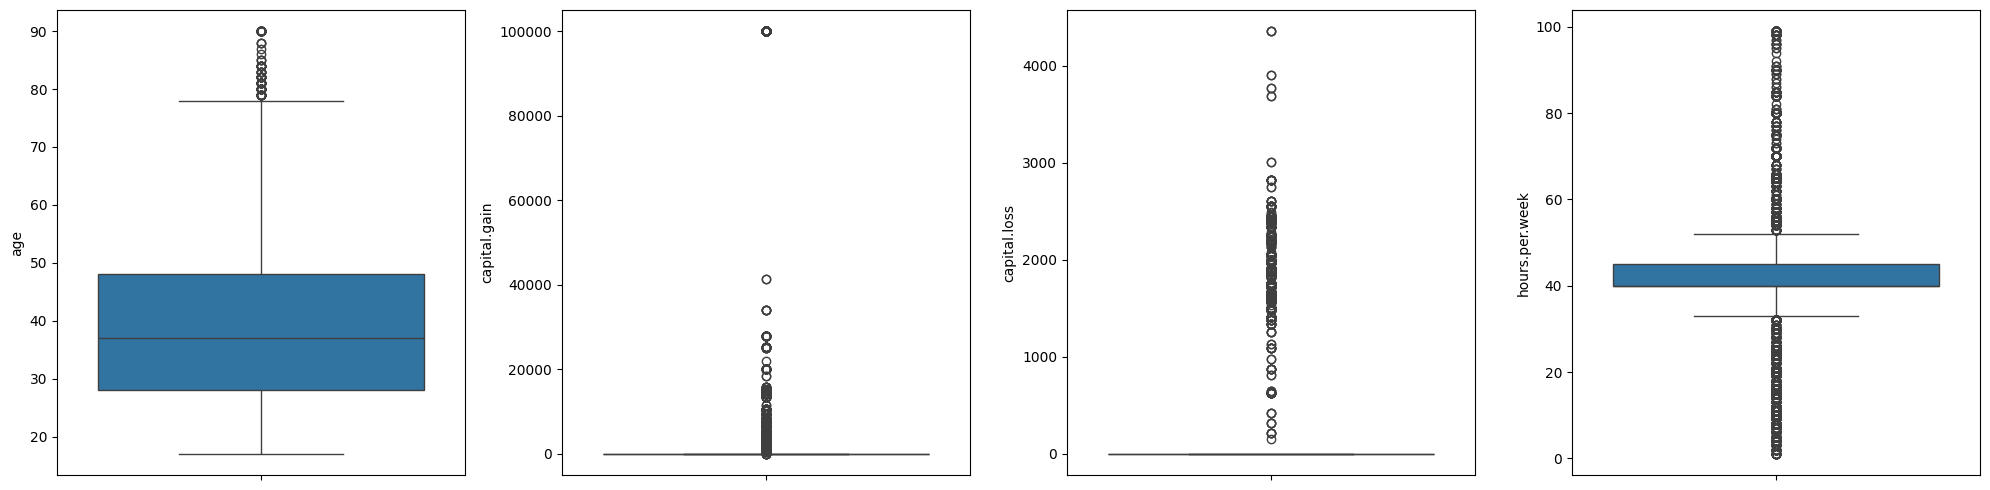

In [11]:
# Duplicate check
print(f"Duplicate rows: {df.duplicated().sum()}")

# Outlier check — box plots for numerical columns
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sns.boxplot(y=df.age, ax=axes[0])
sns.boxplot(y=df['capital.gain'], ax=axes[1])
sns.boxplot(y=df['capital.loss'], ax=axes[2])
sns.boxplot(y=df['hours.per.week'], ax=axes[3])
plt.tight_layout()

In [12]:
df.drop_duplicates(inplace=True)
print(f"Remaining rows: {len(df)}")

Remaining rows: 29028


<div style="background:linear-gradient(90deg,#4A148C 0%,#7B1FA2 60%,#9C4DCC 100%);padding:20px 26px;border-radius:12px;margin:14px 0;box-shadow:0 2px 6px rgba(74,20,140,.25);">
  <div style="color:#E1BEE7;font-size:13px;letter-spacing:2px;text-transform:uppercase;margin-bottom:2px;">Part 2</div>
  <h1 style="color:#ffffff;margin:0;font-size:28px;font-weight:800;">Exploratory Data Analysis (EDA)</h1>
  <p style="color:#F3E5F5;margin:8px 0 0;font-size:15px;">Ask the right questions before modeling — and answer each one with a visual that ends in a decision.</p>
</div>

### EDA is not a graph gallery

Every visualization must follow one formula. If a chart doesn't produce a *finding*, it doesn't belong in the notebook.

<div style="text-align:center;font-size:17px;margin:14px 0;color:#4A148C;font-weight:700;">
Question → Graph → Finding → Modeling Decision
</div>

| Step | Purpose |
|------|---------|
| **Question** | What must I know before building a model? |
| **Graph** | Visualize the answer |
| **Finding** | What does the data actually say? |
| **Decision** | How does this change my modeling plan? |

**The difference from Part 1:** cleaning made the data *trustworthy*; EDA makes us *informed*.

<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">Q1</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">How is the target distributed?</span>
</div>

The very first question in any classification project: **is the target balanced?** If 99% of rows are one class, "accuracy" becomes meaningless. Let's look.

income
<=50K    21841
>50K      7187
Name: count, dtype: int64

income
<=50K    0.752411
>50K     0.247589
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Income Distribution (Target Variable)')

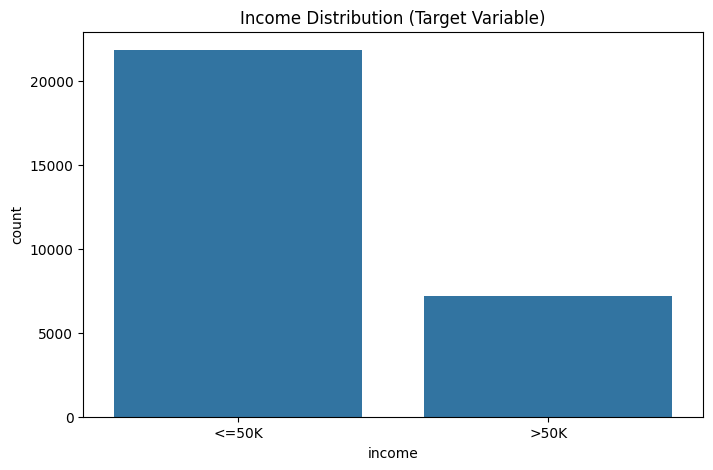

In [13]:
# Q1: How is the target variable distributed?
print(df['income'].value_counts())
print()
print(df['income'].value_counts(normalize=True))

plt.figure(figsize=(8, 5))
sns.countplot(x=df['income'])
plt.title("Income Distribution (Target Variable)")

#### Finding
- **&lt;=50K:** ~21,800 (**75%**) &nbsp;·&nbsp; **&gt;50K:** ~7,200 (**25%**)
- Binary target, **moderate imbalance (~3:1)**.

#### Why this one fact reshapes everything downstream

| Finding | Decision | Reason |
|---------|----------|--------|
| Imbalanced 75/25 | **Don't trust accuracy** | A model that always says "&lt;=50K" scores 75% while learning *nothing* |
| Goal: catch the &gt;50K earners | Prioritize **Recall**, plus **F1 / F2** | Missing a high earner (false negative) is the costly mistake |
| Model may ignore the minority class | Use `class_weight='balanced'` | Forces the model to pay attention to &gt;50K |
| Fair evaluation | `train_test_split(..., stratify=y)` | Keeps the 75/25 ratio in both train and test |

<div style="background:#FFF8E1;border-left:5px solid #F9A825;padding:10px 16px;border-radius:6px;margin:12px 0;">
<b>💡 Takeaway.</b> <b>Finding</b> = what the data shows (75/25 split). <b>Decision</b> = what you do about it (drop accuracy, use F1/recall, stratify). Keep the two separate in your head — the cell should explain itself.
</div>

<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">2.1</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">Bivariate Analysis — each feature vs. income</span>
</div>

Now the target enters the picture. For every feature we ask a single question: **does this feature separate the two income groups?** If yes, it's a useful predictor.

- **Numerical feature vs. target** → split the distribution by class and compare (**KDE / box plot**). Two curves that pull apart = strong signal.
- **Categorical feature vs. target** → compare the **&gt;50K rate** per category (a *proportion*, never a raw count). The trap beginners fall into: plotting counts. "Private is the biggest group" tells you nothing about income — the *rate* does.

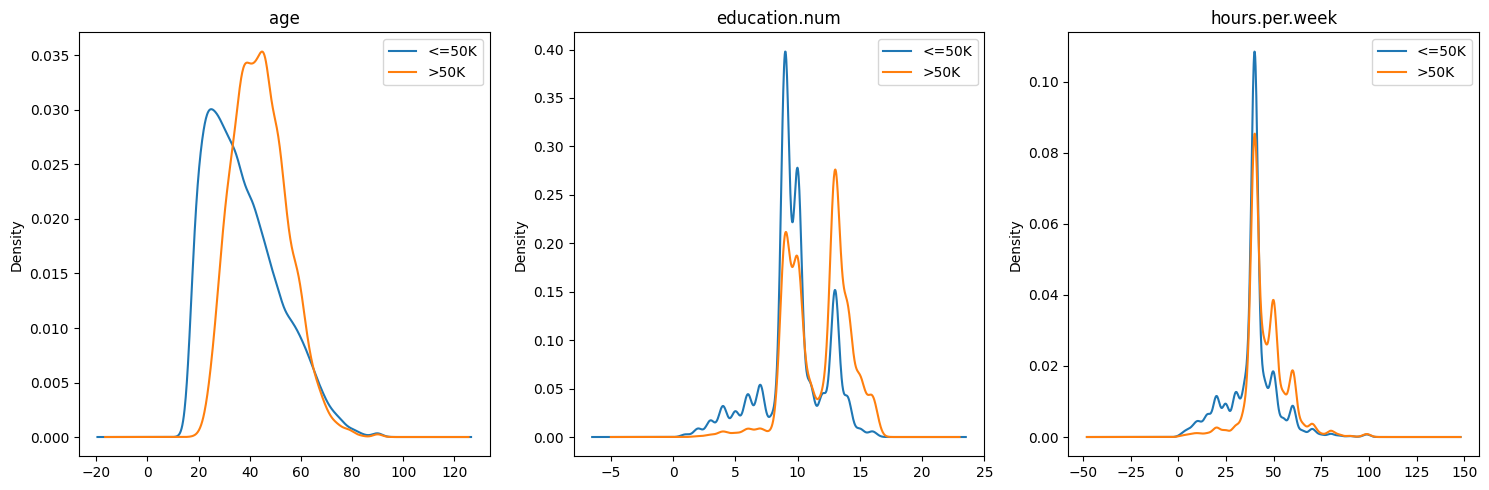

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(['age', 'education.num', 'hours.per.week']):
    df.groupby('income')[col].plot(kind='kde', ax=axes[i], legend=True)
    axes[i].set_title(col)
plt.tight_layout()

In [15]:
# What % of each income group has capital gain/loss?
print("capital.gain > 0 oranı:")
print(df.groupby('income')['capital.gain'].apply(lambda x: (x > 0).mean()))
print("\ncapital.loss > 0 oranı:")
print(df.groupby('income')['capital.loss'].apply(lambda x: (x > 0).mean()))


capital.gain > 0 oranı:
income
<=50K    0.047342
>50K     0.231529
Name: capital.gain, dtype: float64

capital.loss > 0 oranı:
income
<=50K    0.034064
>50K     0.106720
Name: capital.loss, dtype: float64


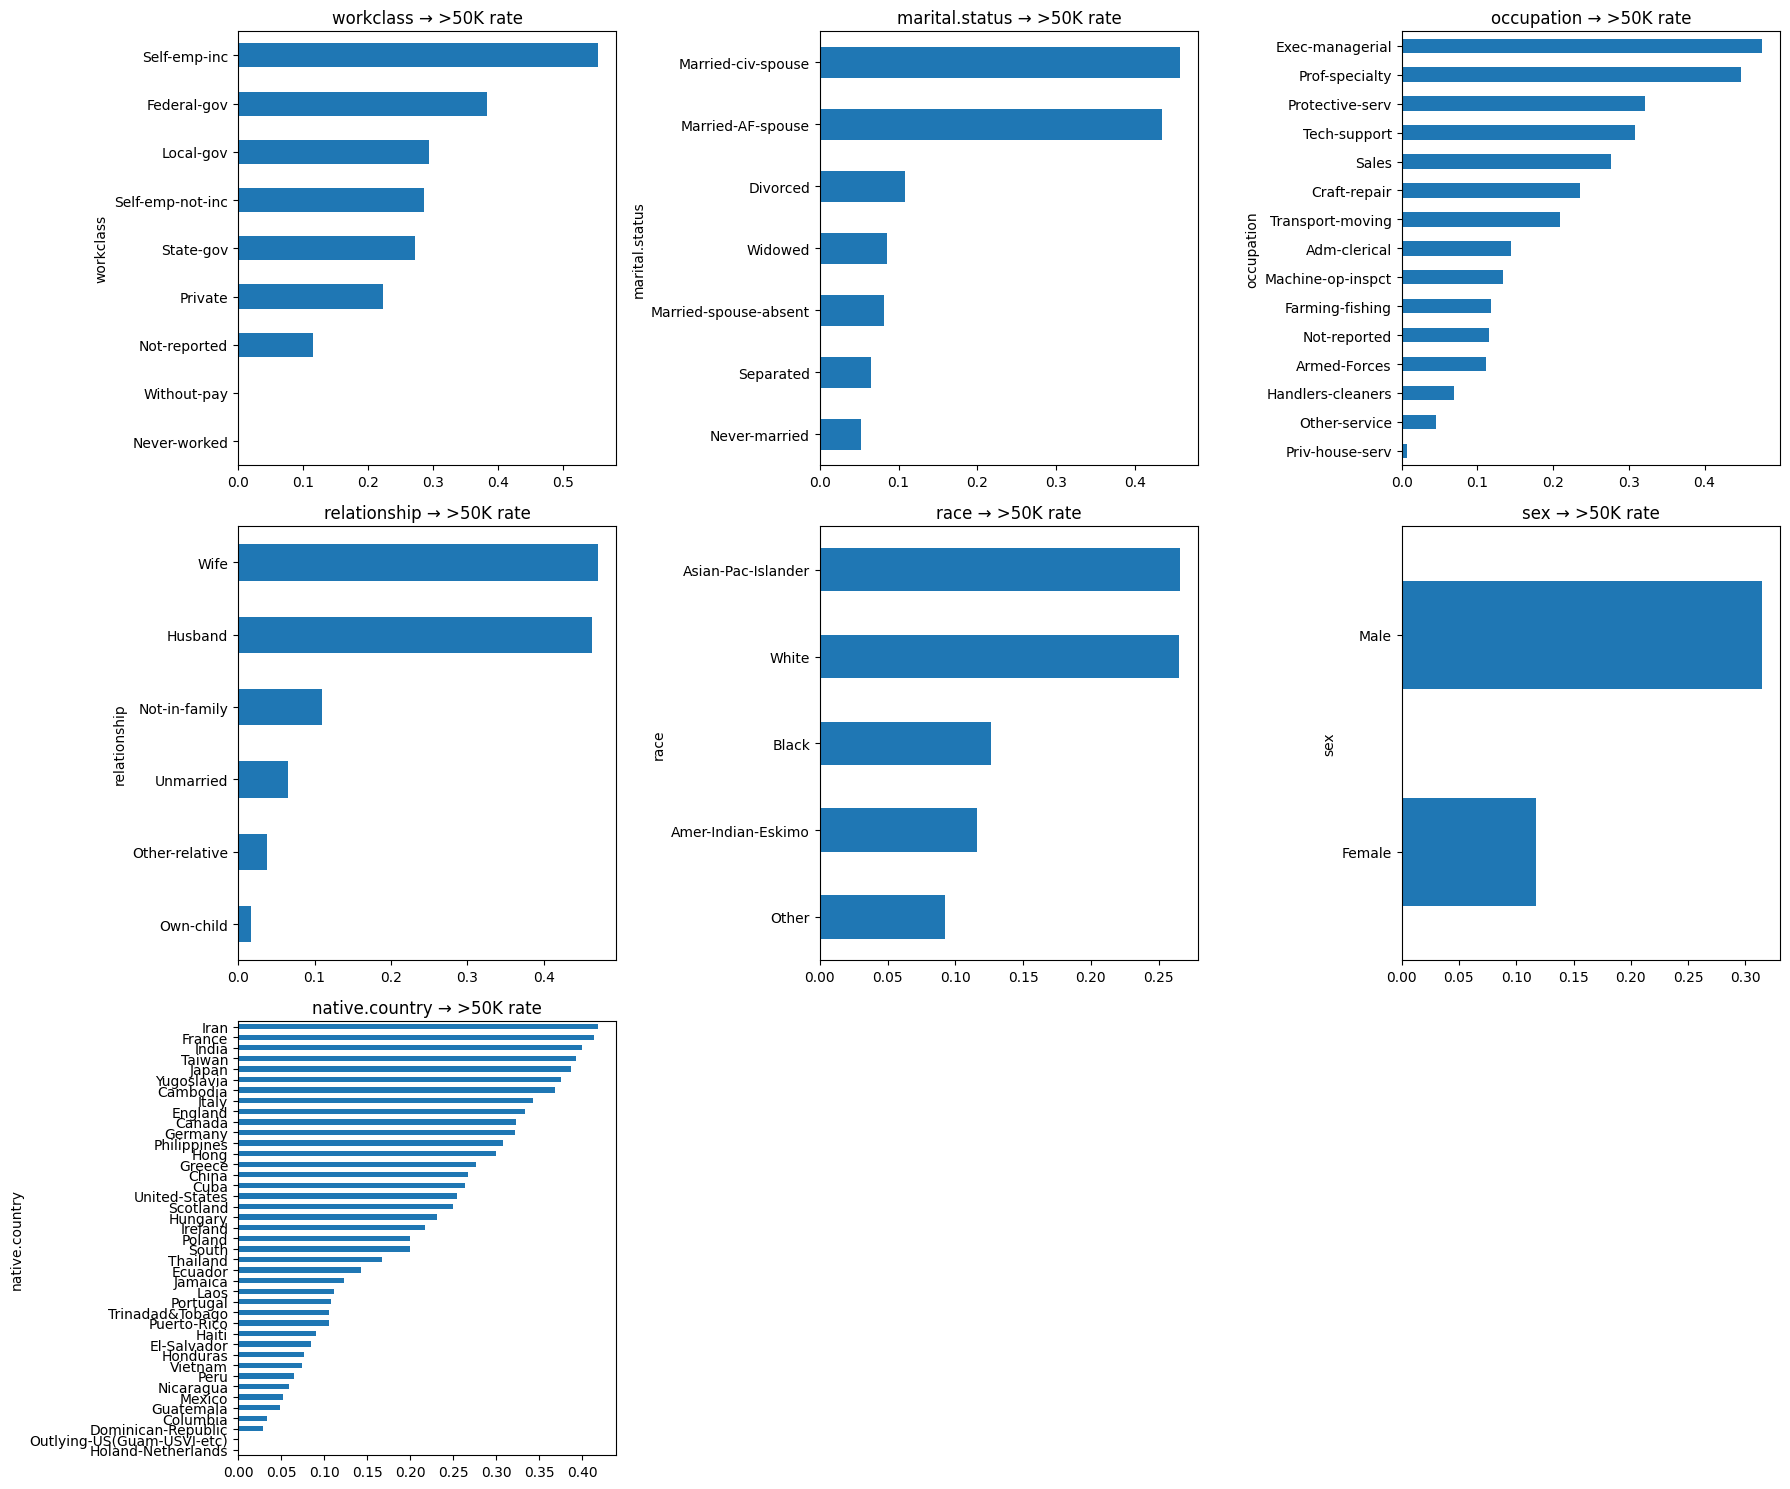

In [16]:
cat_cols = [c for c in df.select_dtypes(include='object').columns if c != 'income']
n = len(cat_cols)
fig, axes = plt.subplots((n+2)//3, 3, figsize=(18, 5*((n+2)//3)))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    (df.groupby(col)['income']
       .apply(lambda x: (x == '>50K').mean())
       .sort_values()
       .plot(kind='barh', ax=axes[i]))
    axes[i].set_title(f'{col} → >50K rate')

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

#### Findings — numerical features (KDE)
| Feature | Finding | Predictive power |
|---------|---------|------------------|
| age | &gt;50K peaks at 40–50, &lt;=50K at 25–30 | **Strong** |
| education.num | &gt;50K concentrated at 13–16 (Bachelors+) | **Strong** |
| hours.per.week | &gt;50K shifted toward 40+ hours | Moderate |

#### Findings — the "mostly-zero" money columns
| Feature | &lt;=50K has it | &gt;50K has it | Reading |
|---------|:---:|:---:|---------|
| capital.gain &gt; 0 | 4.7% | 23.2% | **5× more likely** in high earners |
| capital.loss &gt; 0 | 3.4% | 10.7% | 3× more likely — investors earn more |

#### Findings — categorical features (>50K rate)
- `marital.status` and `relationship` are the **strongest** separators — but they overlap heavily (redundancy flag).
- `occupation` separates well but has many categories (watch encoding).
- `native.country` is 90% one value across 40+ categories (collapse it).
- `sex` and `race` show large income gaps — **protected attributes** (handled in 2.4).

<div style="background:#FFF8E1;border-left:5px solid #F9A825;padding:10px 16px;border-radius:6px;margin:12px 0;">
<b>💡 Takeaway.</b> Each finding becomes a concrete action in Part 3: create <code>has_capital_gain</code>, collapse <code>native.country</code>, test dropping the redundant column, and so on. This table <i>is</i> the feature-engineering to-do list.
</div>

<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">2.3</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">Feature ↔ Feature relationships</span>
</div>

A different question now — **not** "does this predict income?" but "do two features say the *same thing*?" If they do, one is redundant. Keeping both causes **multicollinearity**: the model splits one effect across two columns, making coefficients unstable and unreadable.

- Numerical ↔ numerical → **correlation matrix** (heatmap).
- Categorical ↔ categorical → **crosstab** (does one column give away the other?).

relationship,Husband,Not-in-family,Other-relative,Own-child,Unmarried,Wife
marital.status,,,,,,
Divorced,0.00,0.54,0.03,0.08,0.36,0.00
Married-AF-spouse,0.39,0.00,0.04,0.04,0.00,0.52
Married-civ-spouse,0.87,0.00,0.01,0.01,0.00,0.11
Married-spouse-absent,0.00,0.50,0.08,0.11,0.31,0.00
Never-married,0.00,0.46,0.07,0.38,0.09,0.00
Separated,0.00,0.41,0.05,0.10,0.44,0.00
Widowed,0.00,0.55,0.05,0.02,0.39,0.00


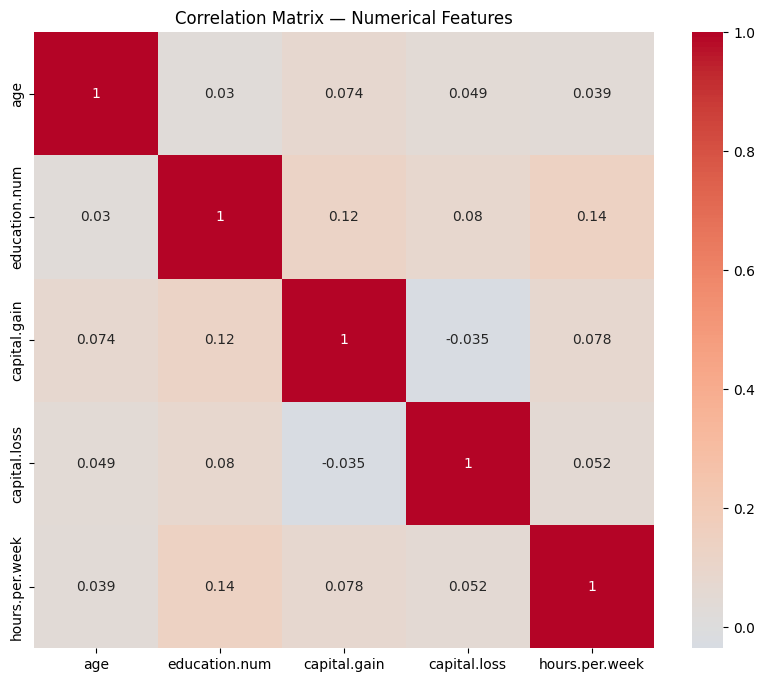

In [17]:
# Correlation matrix — numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix — Numerical Features")

# Check marital.status vs relationship overlap
pd.crosstab(df['marital.status'], df['relationship'], normalize='index').round(2)

#### Findings
- **Numerical features:** every correlation is below **0.14** → no multicollinearity, keep all numerical columns.
- **`marital.status` ≈ `relationship`:** the crosstab shows "Married-civ-spouse" → "Husband" ~87% of the time. These two encode nearly identical information.

**Decision:** keep **one** of the pair. We'll keep `relationship` (a slightly stronger predictor) and drop `marital.status` in Part 3.

<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">2.4</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">Fairness — protected attributes</span>
</div>

**Why this belongs in EDA, before any model exists.** `sex` and `race` are *protected attributes*: features where group differences come from historical/societal inequality, not individual merit. A model trained naively will learn those inequalities as if they were predictive rules.

In [18]:
# Fairness check: >50K rate by sex and race
print("=== Income by Sex ===")
print(df.groupby('sex')['income'].apply(lambda x: (x == '>50K').mean()).round(3))
print(f"\nMale count: {(df.sex == 'Male').sum()}, Female count: {(df.sex == 'Female').sum()}")

print("\n=== Income by Race ===")
print(df.groupby('race')['income'].apply(lambda x: (x == '>50K').mean()).round(3))
print(df.race.value_counts())

=== Income by Sex ===
sex
Female    0.117
Male      0.314
Name: income, dtype: float64

Male count: 19195, Female count: 9833

=== Income by Race ===
race
Amer-Indian-Eskimo    0.116
Asian-Pac-Islander    0.266
Black                 0.127
Other                 0.092
White                 0.265
Name: income, dtype: float64
race
White                 24376
Black                  3032
Asian-Pac-Islander     1038
Amer-Indian-Eskimo      311
Other                   271
Name: count, dtype: int64


#### Observed disparities
| Attribute | Group | &gt;50K rate | Sample size |
|-----------|-------|:---:|:---:|
| sex | Male | 31.4% | 19,195 |
| sex | Female | 11.7% | 9,833 |

Men are labelled high-income **~2.7× more often** than women in this data.

<div style="background:#F3E5F5;border-left:5px solid #7B1FA2;padding:10px 16px;border-radius:6px;margin:12px 0;">
<b>The proxy problem.</b> Deleting <code>sex</code> does <b>not</b> make the model fair — this is the classic <i>"fairness through unawareness"</i> fallacy. Columns like <code>relationship</code> ("Husband"/"Wife") and <code>occupation</code> leak gender indirectly, so the model can rediscover it. The right move isn't blind deletion — it's to <b>measure fairness on the model's outputs</b> (we do this in Part 4.6).
</div>

<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">2.5</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">EDA Summary — findings → decisions</span>
</div>

Everything above, condensed into an action plan. Every row here becomes a concrete step in Part 3 or Part 4.

| # | Finding | Decision | Phase |
|---|---------|----------|-------|
| 1 | Target imbalanced 75/25 | stratify split, `class_weight='balanced'`, judge by F1/F2 not accuracy | Modeling |
| 2 | age predicts income | Keep as-is | FE |
| 3 | education.num strong linear signal | Keep as-is | — |
| 4 | capital.gain/loss 90%+ zero, but non-zero is a strong signal | Create `has_capital_gain`, `has_capital_loss` + log-transform | FE |
| 5 | hours.per.week: &gt;50K works more | Create `works_overtime` (&gt;40) | FE |
| 6 | relationship ≈ marital.status (87% overlap) | Drop `marital.status`, keep `relationship` | FE |
| 7 | occupation strong but 15 categories | Keep; one-hot encode | FE |
| 8 | native.country: 90% US, 40+ categories | Collapse to `is_us` | FE |
| 9 | sex/race: protected attributes with disparity | Measure recall gap across groups after modeling | Modeling |
| 10 | numerical features: no multicollinearity | No numerical drops | — |

<div style="background:linear-gradient(90deg,#4A148C 0%,#7B1FA2 60%,#9C4DCC 100%);padding:20px 26px;border-radius:12px;margin:14px 0;box-shadow:0 2px 6px rgba(74,20,140,.25);">
  <div style="color:#E1BEE7;font-size:13px;letter-spacing:2px;text-transform:uppercase;margin-bottom:2px;">Part 3</div>
  <h1 style="color:#ffffff;margin:0;font-size:28px;font-weight:800;">Feature Engineering</h1>
  <p style="color:#F3E5F5;margin:8px 0 0;font-size:15px;">Reshape the data into the form a model learns from best. Every choice below is a treatment for a Part-2 diagnosis.</p>
</div>

### The one goal of feature engineering

> **Turn the data into the form a model can learn from most easily.**

A model is like a literal-minded student: give it raw, messy input and it learns poorly; give it clean, flat, numeric, well-shaped input and it learns well. Everything below serves that one sentence.

**Roadmap** (and where each step already happened):

| # | Step | Status |
|---|------|--------|
| 1 | Handle missing values | ✅ Done in Part 1 (`Not-reported`, mode fill) |
| 2 | Create new features | ⬇️ This section |
| 3 | Drop redundant features | ⬇️ This section |
| 4 | Transform skewed features | ⬇️ This section |
| 5 | Encode categoricals → numbers | ⬇️ This section |
| 6 | Train/test split | ⬇️ This section |
| 7 | Scale | ⬇️ This section |

<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">3.1</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">Creating new features</span>
</div>

**What we did.** Built four brand-new columns from existing ones: `has_capital_gain`, `has_capital_loss`, `works_overtime`, `is_us`.

**Why.** A raw column sometimes hides its signal. `hours.per.week` is a continuous number (17, 40, 60…), but the thing that actually matters is often *"does this person work overtime?"* — a yes/no. By building `works_overtime` we hand that insight to the model directly, instead of hoping it rediscovers the 40-hour threshold on its own. Same logic for `has_capital_gain`: the column is 90% zeros, and simply *"do they have any capital gain at all?"* is a powerful clue (5× more common among high earners, per EDA).

**How.** Turn a condition into 1/0: `(df['hours.per.week'] > 40).astype(int)` → True becomes 1, False becomes 0.

<div style="background:#FFF8E1;border-left:5px solid #F9A825;padding:10px 16px;border-radius:6px;margin:12px 0;">
<b>💡 Takeaway.</b> A good engineered feature is <b>domain knowledge baked into a column</b> — you're teaching the model something you already know, so it doesn't have to learn it the hard way.
</div>

In [19]:
# Feature Engineering Step 1: Create new features from EDA findings

# Binary: has capital gain
df['has_capital_gain'] = (df['capital.gain'] > 0).astype(int)

# Binary: has capital loss
df['has_capital_loss'] = (df['capital.loss'] > 0).astype(int)

# Binary: works overtime
df['works_overtime'] = (df['hours.per.week'] > 40).astype(int)

# Group native.country: US vs Other
df['is_us'] = (df['native.country'] == 'United-States').astype(int)

df[['has_capital_gain', 'has_capital_loss', 'works_overtime', 'is_us']].head(10)

,has_capital_gain,has_capital_loss,works_overtime,is_us
0,0,1,0,1
1,0,1,0,1
2,0,1,0,1
3,0,1,0,1
4,0,1,0,1
5,0,1,1,1
6,0,1,0,1
7,0,1,0,1
8,0,1,0,1
9,0,1,1,1


<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">3.2</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">Dropping redundant columns + fixing skew</span>
</div>

**Dropping redundancy** (the feature ↔ feature lesson from EDA). If two columns carry the same information, one is dead weight — it causes multicollinearity and bloats the model.

| Dropped | Reason | Kept instead |
|---------|--------|--------------|
| `native.country` | 40+ sparse categories, 90% one value → noise | `is_us` |
| `marital.status` | 87% overlap with `relationship` | `relationship` |
| `education` | text duplicate of `education.num` (dropped in Part 1) | `education.num` |
| `fnlwgt` | census sampling weight, not a predictor (dropped in Part 1) | — |
| raw `capital.gain/loss` | replaced by log versions (below); the raw + log pair is ~100% correlated | `.log` versions |

**Fixing skew with a log transform.** `capital.gain` and `capital.loss` are extremely *skewed* — mostly zero, with a few enormous values (up to 99,999). Skew distorts scaling and misleads many models. `np.log1p` = `log(1 + x)` squashes the giants and pulls the shape toward normal.

*Why `log1p` and not plain `log`?* Because `log(0)` is undefined (−∞), but `log1p(0) = log(1) = 0`. With a column full of zeros, `log1p` handles them safely.

<div style="background:#FFF8E1;border-left:5px solid #F9A825;padding:10px 16px;border-radius:6px;margin:12px 0;">
<b>💡 Takeaway.</b> Keep the signal, drop the copy. &quot;More columns = better model&quot; is <b>false</b> — redundancy and noise hurt. And skewed continuous values usually want a log.
</div>

In [20]:

# 1. Drop native.country (is_us replaces it)
df.drop(columns=['native.country'], inplace=True)

# 2. Drop marital.status (relationship is stronger predictor, covers same info)
df.drop(columns=['marital.status'], inplace=True)

# 3. Log transform capital.gain and capital.loss (handle zeros with log1p)
df['capital.gain.log'] = np.log1p(df['capital.gain'])
df['capital.loss.log'] = np.log1p(df['capital.loss'])

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape: (29028, 17)
Columns: ['age', 'workclass', 'education.num', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'income', 'has_capital_gain', 'has_capital_loss', 'works_overtime', 'is_us', 'capital.gain.log', 'capital.loss.log']


<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">3.3</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">Encoding — turning words into numbers</span>
</div>

Models only understand numbers, so every text column must be converted. **How** you convert matters:

| Column | Method | Why |
|--------|--------|-----|
| `sex` (2 values) | Binary map (Male=1, Female=0) | Only two options → one 0/1 column is enough |
| `income` (target, 2 values) | Binary map (&gt;50K=1, &lt;=50K=0) | The target must be numeric too |
| `workclass`, `occupation`, `relationship`, `race` | One-hot (`get_dummies`) | Many **unordered** categories |

**Why one-hot for the multi-category ones?** If we mapped occupations to 1, 2, 3…, the model would invent a fake ranking ("occupation 3 > occupation 1"). Jobs have no such order. One-hot gives each category its own 0/1 column, killing that false ordering.

**`drop_first=True`** removes one redundant dummy per feature (if all others are 0, the last is implied). This avoids the *dummy variable trap* — another form of multicollinearity. The dropped category becomes the "baseline."

<div style="background:#E8EAF6;border-left:5px solid #3949AB;padding:10px 16px;border-radius:6px;margin:12px 0;">
<b>ℹ️ Note.</b> We also convert the boolean dummies to <code>int</code> (True→1, False→0) for clean, model-friendly output.
</div>

In [21]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

workclass: 9 unique values
occupation: 15 unique values
relationship: 6 unique values
race: 5 unique values
sex: 2 unique values
income: 2 unique values


In [22]:
# Binary encoding — sex and income (target)
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
df['income'] = df['income'].map({'>50K': 1, '<=50K': 0})

# One-hot encoding — remaining categoricals
df = pd.get_dummies(df, columns=['workclass', 'occupation', 'relationship', 'race'], drop_first=True)

print(f"Shape: {df.shape}")
df.head()

Shape: (29028, 44)


,age,education.num,sex,capital.gain,capital.loss,hours.per.week,income,has_capital_gain,has_capital_loss,works_overtime,...,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,90,9,0,0,4356,40,0,0,1,0,...,False,True,False,False,False,False,False,False,False,True
1,82,9,0,0,4356,18,0,0,1,0,...,False,True,False,False,False,False,False,False,False,True
2,66,10,0,0,4356,40,0,0,1,0,...,False,False,False,False,True,False,False,True,False,False
3,54,4,0,0,3900,40,0,0,1,0,...,False,False,False,False,True,False,False,False,False,True
4,41,10,0,0,3900,40,0,0,1,0,...,False,False,False,True,False,False,False,False,False,True


In [23]:
# Convert boolean columns to int (True→1, False→0)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"Final shape: {df.shape}")
print(df.dtypes.value_counts())




Final shape: (29028, 44)
int64      42
float64     2
Name: count, dtype: int64


<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">3.4</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">Train/test split + scaling (and the #1 trap)</span>
</div>

**Split first.** We hold out 20% of the data that the model will *never see* during training — the only honest way to measure whether it truly learned or just memorized.

- `stratify=y` keeps the 75/25 imbalance identical in both train and test (the EDA decision).
- `random_state=42` makes the split reproducible — you and I get the exact same rows.

**Then scale.** `age` (17–90), `education.num` (1–16) and the log columns live on very different scales. Distance/coefficient-based models (Logistic Regression, KNN, SVM) would wrongly treat the big-numbered column as "more important." `StandardScaler` puts everything on a mean-0, std-1 footing. *(Tree models like Random Forest / XGBoost don't need this — but scaling doesn't hurt them.)*

<div style="background:#FDECEA;border-left:5px solid #E53935;padding:10px 16px;border-radius:6px;margin:12px 0;">
<b>⚠️ Data leakage — the single most important line in this notebook.</b> The scaler is <code>fit</code> on <b>train only</b>, then merely <code>transform</code>s the test set. If you fit on all the data, the test set's statistics leak into training — your scores look great and then collapse in the real world. <b>The test set is the future; you cannot learn from the future.</b>
</div>

In [24]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['income'])
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows")
print(f"Test: {X_test.shape[0]} rows")
print(f"\nTrain target distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True).round(3)}")

from sklearn.preprocessing import StandardScaler

# First drop raw capital columns (log versions replace them)
X_train = X_train.drop(columns=['capital.gain', 'capital.loss'], errors='ignore')
X_test = X_test.drop(columns=['capital.gain', 'capital.loss'], errors='ignore')

# Then scale
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Shape: {X_train_scaled.shape}")
print(f"Columns: {X_train_scaled.columns.tolist()}")

Train: 23222 rows
Test: 5806 rows

Train target distribution:
income
0    0.752
1    0.248
Name: proportion, dtype: float64

Test target distribution:
income
0    0.752
1    0.248
Name: proportion, dtype: float64
Shape: (23222, 41)
Columns: ['age', 'education.num', 'sex', 'hours.per.week', 'has_capital_gain', 'has_capital_loss', 'works_overtime', 'is_us', 'capital.gain.log', 'capital.loss.log', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Not-reported', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Not-reported', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Transport-moving', 'r

<div style="background:linear-gradient(90deg,#4A148C 0%,#7B1FA2 60%,#9C4DCC 100%);padding:20px 26px;border-radius:12px;margin:14px 0;box-shadow:0 2px 6px rgba(74,20,140,.25);">
  <div style="color:#E1BEE7;font-size:13px;letter-spacing:2px;text-transform:uppercase;margin-bottom:2px;">Part 4</div>
  <h1 style="color:#ffffff;margin:0;font-size:28px;font-weight:800;">Modeling &amp; Fairness</h1>
  <p style="color:#F3E5F5;margin:8px 0 0;font-size:15px;">Train several models, judge them by the metrics that actually matter here, then audit the winner for fairness.</p>
</div>

### Strategy

- **Primary metric: Recall** (catch the &gt;50K earners) balanced with **F1** — *not* accuracy (a do-nothing model already scores 75%).
- Use `class_weight='balanced'` so the model can't ignore the minority class.
- **Compare three models** of increasing power, then audit the best one for fairness:

<div style="text-align:center;font-size:15px;margin:12px 0;color:#4A148C;font-weight:600;">
Logistic Regression &nbsp;→&nbsp; Random Forest &nbsp;→&nbsp; XGBoost &nbsp;→&nbsp; Fairness audit
</div>

<div style="background:#E8EAF6;border-left:5px solid #3949AB;padding:10px 16px;border-radius:6px;margin:12px 0;">
<b>ℹ️ Note.</b> Reading a classification report: <b>precision</b> = of the ones I flagged as &gt;50K, how many really were. <b>recall</b> = of the true &gt;50K people, how many I caught. <b>F1</b> = the balance of the two. Focus on the row for class <b>1</b> (&gt;50K) — that's the minority class we care about.
</div>

<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">4.1</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">Logistic Regression — the transparent baseline</span>
</div>

**What it is.** A linear model: it multiplies each feature by a weight and adds them up to estimate the probability of &gt;50K. Simple, fast, and **interpretable** — you can read the weights.

**Why start here.** Always begin with the simplest reasonable model. It sets a baseline that fancier models must beat, and if a linear model already does well, you've learned the problem is mostly linear. `class_weight='balanced'` tells it to treat the rare &gt;50K class as equally important.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Logistic Regression with class_weight='balanced'
log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

print("=== LOGISTIC REGRESSION (balanced) ===")
print(classification_report(y_test, y_pred_log))

=== LOGISTIC REGRESSION (balanced) ===
              precision    recall  f1-score   support

           0       0.94      0.80      0.86      4369
           1       0.58      0.84      0.69      1437

    accuracy                           0.81      5806
   macro avg       0.76      0.82      0.78      5806
weighted avg       0.85      0.81      0.82      5806



**Result.** Recall on &gt;50K = **0.84** (catches 84% of high earners) but precision only **0.58** — lots of false alarms. F1 = **0.69**. A strong, honest baseline.

<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">4.2</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">Random Forest — many trees voting</span>
</div>

**What it is.** An *ensemble* of hundreds of decision trees; each tree votes, the majority wins. It captures non-linear patterns and interactions a linear model can't.

**Why.** It's a natural next step up in power and usually robust with little tuning. Note it doesn't need the scaling we did — trees split on thresholds, not distances — but leaving the scaled data in place does no harm.

In [26]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest — doesn't need scaling, but works fine with it
rf_model = RandomForestClassifier(
    class_weight='balanced', 
    n_estimators=100, 
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print("=== RANDOM FOREST (balanced) ===")
print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST (balanced) ===
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      4369
           1       0.68      0.59      0.64      1437

    accuracy                           0.83      5806
   macro avg       0.78      0.75      0.76      5806
weighted avg       0.83      0.83      0.83      5806



**Result.** Higher precision (**0.68**) but recall drops to **0.59** — it plays it safe and *misses* many high earners. Since our priority is recall, this is actually a **step back** for our goal, despite the higher overall accuracy (0.83). A perfect illustration of why accuracy is the wrong lens here.

<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">4.3</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">XGBoost — gradient boosting</span>
</div>

**What it is.** Also a tree ensemble, but the trees are built **sequentially**, each one correcting the previous one's mistakes ("boosting"). Often the top performer on tabular data.

**Why.** To see whether a more sophisticated model buys us a better recall/precision trade-off. For imbalance we use `scale_pos_weight` (XGBoost's version of `class_weight='balanced'`).

In [27]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight for imbalance
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    scale_pos_weight=scale_weight,
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("=== XGBOOST (balanced) ===")
print(classification_report(y_test, y_pred_xgb))

=== XGBOOST (balanced) ===
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      4369
           1       0.63      0.84      0.72      1437

    accuracy                           0.84      5806
   macro avg       0.78      0.84      0.80      5806
weighted avg       0.86      0.84      0.84      5806



<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">4.4</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">Model comparison — picking the winner</span>
</div>

All three, side by side, focused on the **&gt;50K class** (the one that matters):

| Model | Recall (&gt;50K) | Precision (&gt;50K) | F1 (&gt;50K) | Accuracy |
|-------|:---:|:---:|:---:|:---:|
| Logistic Regression | 0.84 | 0.58 | 0.69 | 0.81 |
| Random Forest | 0.59 | 0.68 | 0.64 | 0.83 |
| **XGBoost** ✅ | **0.84** | **0.63** | **0.72** | **0.84** |

**Winner: XGBoost.** It matches Logistic Regression's high recall (0.84) *and* improves precision (0.63 vs 0.58), giving the best F1 (0.72) and the best accuracy. It catches as many high earners as the baseline while raising fewer false alarms.

<div style="background:#FFF8E1;border-left:5px solid #F9A825;padding:10px 16px;border-radius:6px;margin:12px 0;">
<b>💡 Takeaway.</b> Random Forest had the second-best accuracy but the <b>worst recall</b> — if we'd judged by accuracy alone we'd have picked the wrong model for our actual goal. Always match the metric to the mission.
</div>

Below we confirm XGBoost with an **F2 score** (weights recall twice as heavily as precision) and a **confusion matrix** (the raw counts of what it got right and wrong).

F2 Score (XGBoost): 0.785


Text(0.5, 1.0, 'XGBoost — Confusion Matrix')

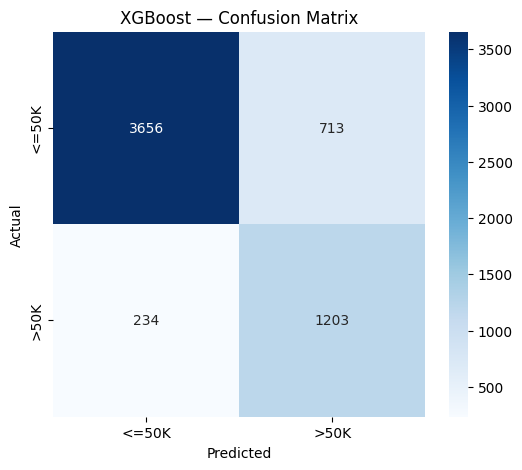

In [28]:
from sklearn.metrics import confusion_matrix, fbeta_score
import seaborn as sns

# F2 score (recall-weighted)
f2 = fbeta_score(y_test, y_pred_xgb, beta=2)
print(f"F2 Score (XGBoost): {f2:.3f}")

# Confusion matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost — Confusion Matrix')

<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">4.5</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">Fairness audit — does the winner treat groups equally?</span>
</div>

Back to the Part-2 warning. XGBoost performs well *overall* — but "overall" can hide that it works better for one group than another. We measure **recall separately for men and women**: of the people who truly earn &gt;50K, what fraction does the model catch in each group?

In [29]:
# Fairness check using unscaled X_test (original 0/1 values)
for sex_val, sex_label in [(1, 'Male'), (0, 'Female')]:
    mask = X_test['sex'] == sex_val
    y_true_group = y_test[mask]
    y_pred_group = y_pred_xgb[mask]
    
    recall = y_pred_group[y_true_group == 1].mean()
    total = mask.sum()
    pos = (y_true_group == 1).sum()
    print(f"{sex_label}: Recall = {recall:.3f} | {pos} positive out of {total} samples")

Male: Recall = 0.866 | 1198 positive out of 3823 samples
Female: Recall = 0.695 | 239 positive out of 1983 samples


<div style="border-left:5px solid #7B1FA2;padding:4px 0 4px 14px;margin:22px 0 10px;">
  <span style="color:#7B1FA2;font-weight:700;font-size:13px;">4.6</span><br>
  <span style="color:#311B45;font-weight:700;font-size:20px;">Fairness findings & responsible disclosure</span>
</div>

| Group | Recall | True &gt;50K | Total |
|-------|:---:|:---:|:---:|
| Male | **86.6%** | 1,198 | 3,823 |
| Female | **69.5%** | 239 | 1,983 |
| **Gap** | **17.1 pp** | | |

**Interpretation.** The model catches **87% of high-income men but only 70% of high-income women** — a 17-point recall gap. The root cause is in the data: there are far fewer &gt;50K women, so the model learned "high income" mostly from male profiles.

**What could fix it (future work).**
- Per-group threshold tuning.
- Resampling the female &gt;50K class.
- Fairness-constrained training (e.g. equalized odds).
- Re-test with/without `relationship`, which leaks gender indirectly.

<div style="background:#FDECEA;border-left:5px solid #E53935;padding:12px 16px;border-radius:6px;margin:12px 0;">
<b>⚠️ Responsible disclosure.</b> This model should <b>not</b> drive consequential decisions (hiring, lending) until this disparity is addressed. For a learning project, <i>measuring and documenting</i> the gap is the minimum responsible step — and it's exactly why we flagged <code>sex</code> and <code>race</code> back in Part 2.
</div>

<div style="background:linear-gradient(90deg,#311B45,#7B1FA2);padding:16px 22px;border-radius:10px;margin:18px 0;color:#fff;">
<b>Full circle.</b> Part 1 made the data trustworthy → Part 2 diagnosed what mattered → Part 3 treated it → Part 4 delivered a model <i>and</i> an honest account of its limits. That last part — knowing where your model fails — is what separates a real project from a leaderboard score.
</div>